# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [4]:
from PIL import Image
import matplotlib.pyplot as plt
from skimage import data


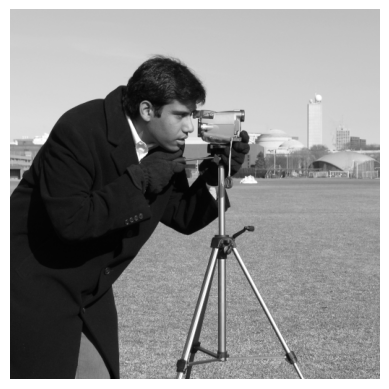

In [5]:
img = data.camera()
img = Image.fromarray(img)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

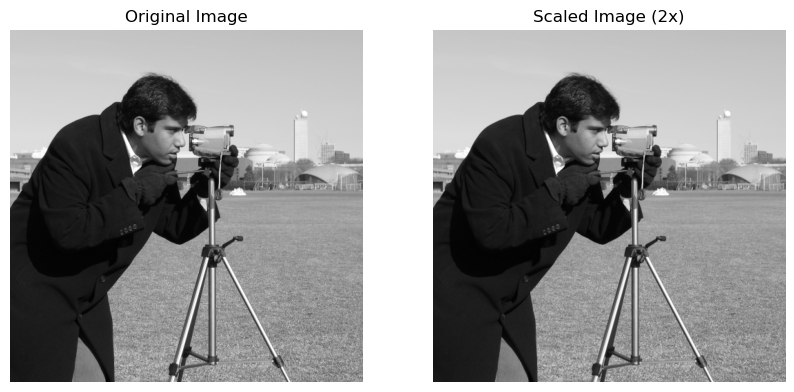

In [8]:
img = Image.fromarray(data.camera())
width, height = img.size

scaled_img = img.resize((width * 2, height * 2), Image.Resampling.LANCZOS)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(scaled_img, cmap="gray")
plt.title("Scaled Image (2x)")
plt.axis("off")

plt.show()

In [9]:
print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

Original size: (512, 512)
Scaled size: (1024, 1024)


In [12]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scaled_img = img.resize(
    (img.width * 2, img.height * 2),
    Image.Resampling.LANCZOS
)


In [13]:

# Save the scaled image and print the sizes

scaled_img.save("task1_1_scaled.jpg")

print("Original image size:", img.size)
print("Scaled image size:", scaled_img.size)

Original image size: (512, 512)
Scaled image size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [14]:

# Stretch the image horizontally only
non_uniform_img = img.resize(
    (img.width * 2, img.height * 1),
    Image.Resampling.LANCZOS
)

# Save the result
non_uniform_img.save("task1_2_nonuniform.jpg")

# Print the sizes
print("Original image size:", img.size)
print("Non-uniform image size:", non_uniform_img.size)

Original image size: (512, 512)
Non-uniform image size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [15]:
# ── 2. Rotate 120° ───────────────────────────────────

# Rotate the image by 120 degrees and expand the canvas
rotated_img = img.rotate(
    120,
    expand=True
)

rotated_img.save("task2_1_rotated.jpg")

# Print the size
print("Original image size:", img.size)
print("Rotated image size:", rotated_img.size)


Original image size: (512, 512)
Rotated image size: (700, 700)


### 3. Shear

In [16]:
width, height = img.size

print("Image width:", width)
print("Image height:", height)

Image width: 512
Image height: 512


In [17]:
shear_factor = 0.5

shear_matrix = (1, shear_factor, 0,
                0, 1, 0)

print("Shear matrix:", shear_matrix)

Shear matrix: (1, 0.5, 0, 0, 1, 0)


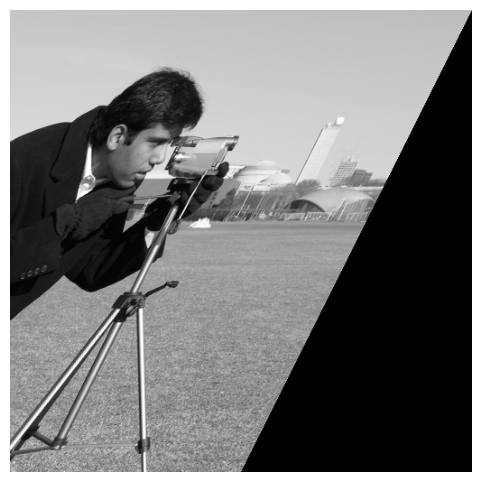

In [19]:
# PIL's transform() takes the inverse affine matrix
sheared_img = img.transform(
    (width, height),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC
)

# Display the sheared image inside Jupyter Notebook
plt.figure(figsize=(6, 6))
plt.imshow(sheared_img, cmap="gray")
plt.axis("off")
plt.show()

In [20]:
sheared_img.save("task1_3_sheared.jpg")

print("Sheared image saved as task1_3_sheared.jpg")

Sheared image saved as task1_3_sheared.jpg


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

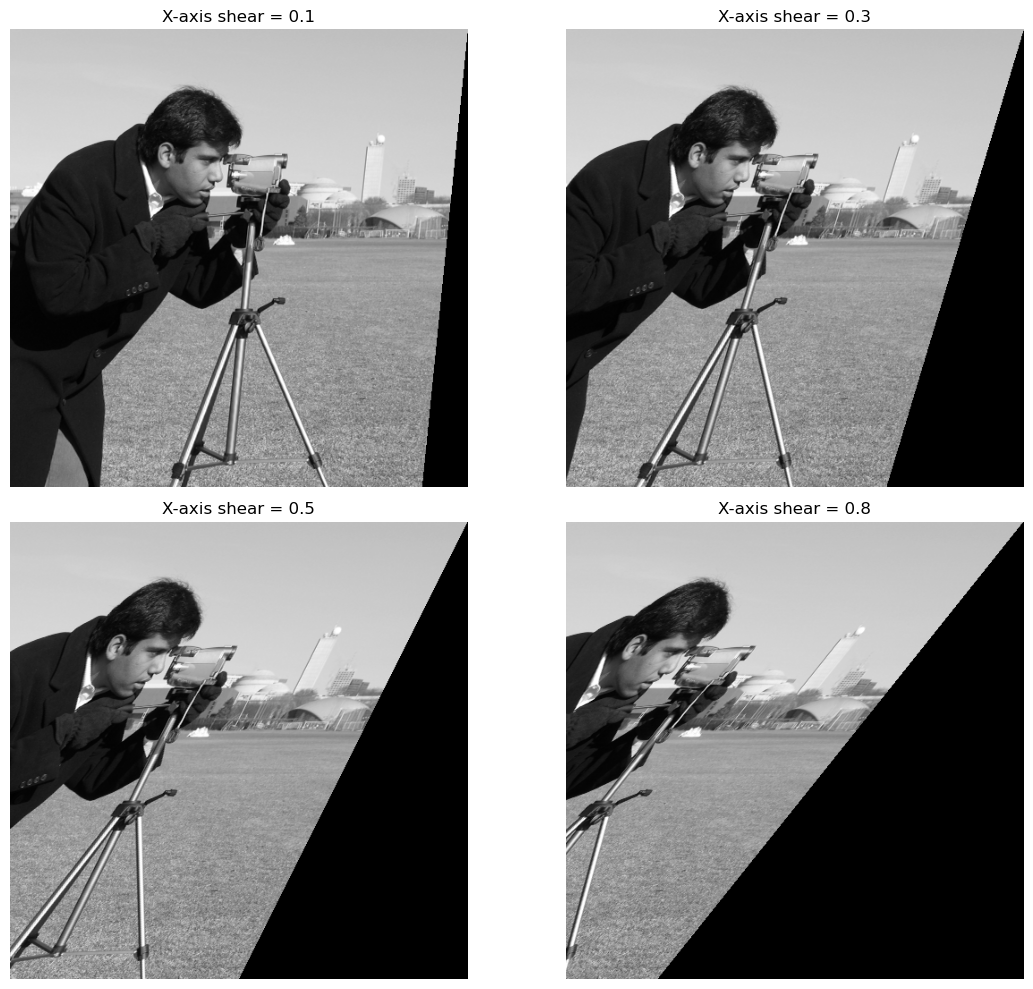

In [21]:
# -- Experiment 1: Compare different X-axis shear factors ─────────────

shear_factors = [0.1, 0.3, 0.5, 0.8]

plt.figure(figsize=(12, 10))

for i, shx in enumerate(shear_factors):
    shear_matrix = (1, shx, 0,
                    0, 1, 0)

    sheared = img.transform(
        (width, height),
        Image.Transform.AFFINE,
        shear_matrix,
        resample=Image.Resampling.BICUBIC
    )

    plt.subplot(2, 2, i + 1)
    plt.imshow(sheared, cmap="gray")
    plt.title(f"X-axis shear = {shx}")
    plt.axis("off")

plt.tight_layout()
plt.show()

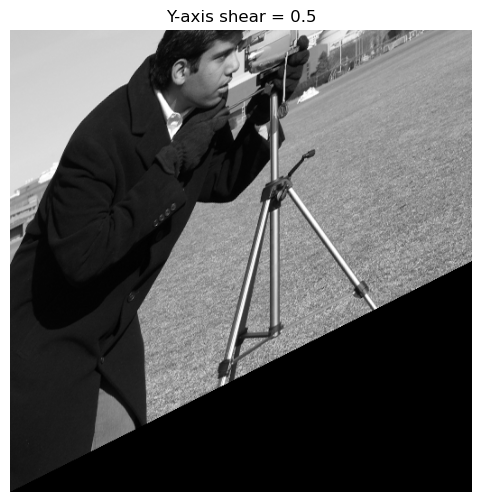

In [22]:
# -- Experiment 2: Y-axis shear ──────────────────────────

shy = 0.5

# Y-axis shear matrix
shear_matrix_y = (1, 0, 0,
                  shy, 1, 0)

sheared_y = img.transform(
    (width, height),
    Image.Transform.AFFINE,
    shear_matrix_y,
    resample=Image.Resampling.BICUBIC
)

# Display inside Jupyter
plt.figure(figsize=(6, 6))
plt.imshow(sheared_y, cmap="gray")
plt.title("Y-axis shear = 0.5")
plt.axis("off")
plt.show()

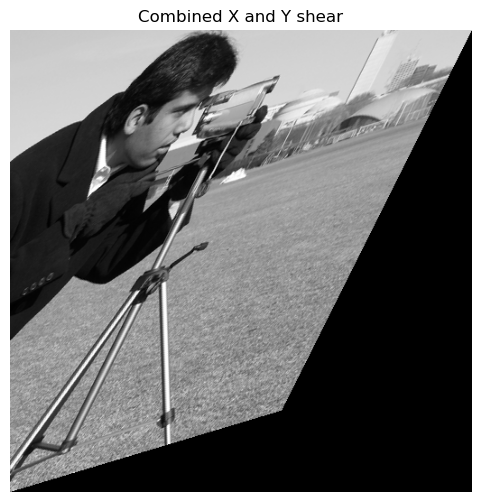

In [23]:
# -- Experiment 3: Combined X and Y shear ───────────────

shx = 0.5
shy = 0.3

# Combined X and Y shear matrix
combined_matrix = (1, shx, 0,
                   shy, 1, 0)

combined_shear = img.transform(
    (width, height),
    Image.Transform.AFFINE,
    combined_matrix,
    resample=Image.Resampling.BICUBIC
)

# Display inside Jupyter
plt.figure(figsize=(6, 6))
plt.imshow(combined_shear, cmap="gray")
plt.title("Combined X and Y shear")
plt.axis("off")
plt.show()

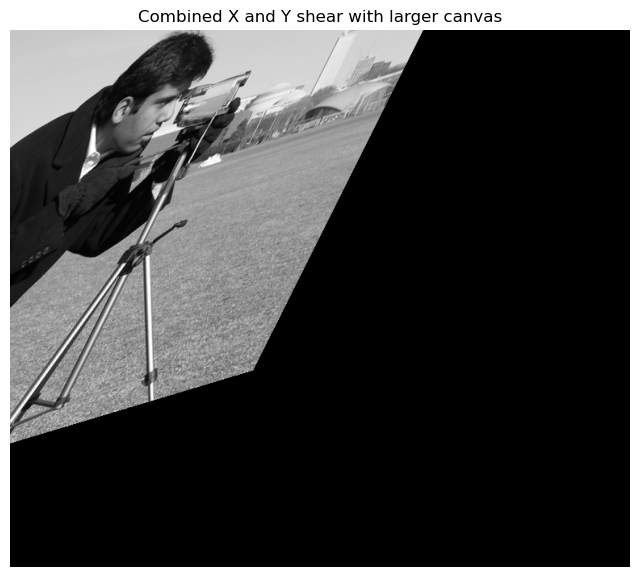

In [24]:
# Increase the canvas size
new_width = int(width * (1 + abs(shx)))
new_height = int(height * (1 + abs(shy)))

combined_shear = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    combined_matrix,
    resample=Image.Resampling.BICUBIC
)

plt.figure(figsize=(8, 8))
plt.imshow(combined_shear, cmap="gray")
plt.title("Combined X and Y shear with larger canvas")
plt.axis("off")
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

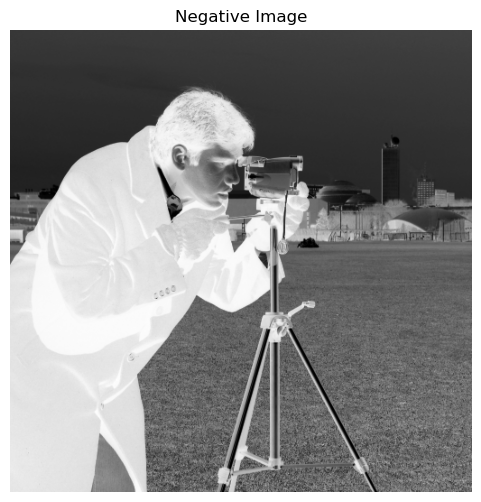

In [25]:
# Method 1: NumPy array manipulation

import numpy as np
import matplotlib.pyplot as plt

img_array = np.array(img)

negative_array = 255 - img_array

negative_img = Image.fromarray(negative_array)

plt.figure(figsize=(6, 6))
plt.imshow(negative_img, cmap="gray")
plt.title("Negative Image")
plt.axis("off")
plt.show()

/var/folders/nw/rx9t3hzd19b04yw3by62_3w80000gn/T/ipykernel_46531/4228369842.py:6: RuntimeWarning: divide by zero encountered in log
  log_array = c * np.log(1 + img_array)
/var/folders/nw/rx9t3hzd19b04yw3by62_3w80000gn/T/ipykernel_46531/4228369842.py:8: RuntimeWarning: invalid value encountered in cast
  log_array = np.uint8(log_array)


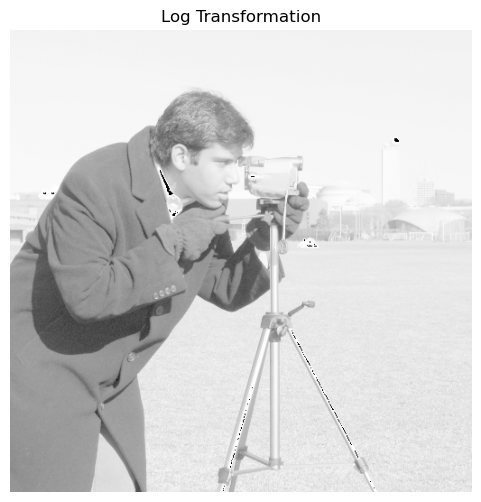

In [26]:
# ── 2. Log transformation ──────────────────────────


c = 255 / np.log(1 + 255)

log_array = c * np.log(1 + img_array)

log_array = np.uint8(log_array)

log_img = Image.fromarray(log_array)

plt.figure(figsize=(6, 6))
plt.imshow(log_img, cmap="gray")
plt.title("Log Transformation")
plt.axis("off")
plt.show()


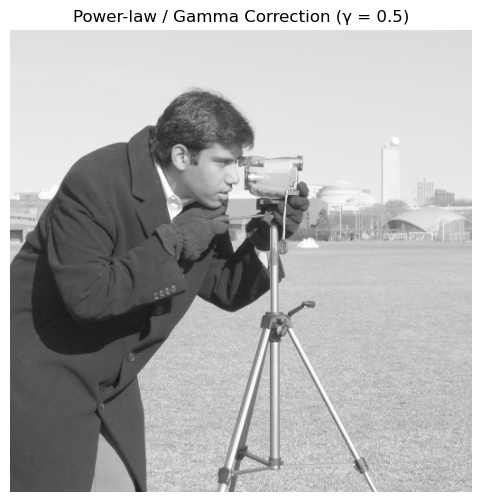

In [27]:
# ── 3. Power-law / Gamma correction ───────────────

gamma = 0.5
normalized = img_array / 255.0

gamma_array = 255 * (normalized ** gamma)

gamma_array = np.uint8(gamma_array)

gamma_img = Image.fromarray(gamma_array)

plt.figure(figsize=(6, 6))
plt.imshow(gamma_img, cmap="gray")
plt.title(f"Power-law / Gamma Correction (γ = {gamma})")
plt.axis("off")
plt.show()